## Exploratory Data Analysis on the Cleaned Glassdoor Dataset

Cleaned Dataset : [salary_data_cleaned.csv](../data/cleaned/salary_data_cleaned.csv)

In [270]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Should give this notebook's directory to access to parent directory by adding it to the python module's search list

For those who are seeing this and don't know what module means (Modules -> .py and .ipynb, Packages -> Directory)

In [271]:
sys.path.append("..")

#### Load the cleaned dataset

In [272]:
df = pd.read_csv("../data/cleaned/salary_data_cleaned.csv")
df.head()

,job_title,salary_estimate,job_description,rating,company_name,location,headquarters,size,founded,type_of_ownership,...,python_yn,r_yn,power_bi_yn,sql_yn,excel_yn,spark_yn,title_simplified,seniority,desc_len,competitor_count
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,True,False,False,False,True,False,data scientist,na,2536,0
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,...,True,True,False,False,False,False,data scientist,na,4783,0
2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,...,True,True,False,True,True,True,data scientist,na,3461,0
3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,...,True,False,False,False,False,False,data scientist,na,3883,3
4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,True,True,False,True,False,False,data scientist,na,2728,3


In [273]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rating,466.0,3.661803,0.776759,-1.0,3.4,3.7,4.1,5.0
founded,466.0,1836.375536,502.044442,-1.0,1939.0,1991.5,2007.0,2019.0
hourly,466.0,0.021459,0.145065,0.0,0.0,0.0,0.0,1.0
employer_provided_salary,466.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
min_salary,466.0,74.278970,30.560067,10.0,53.0,71.0,90.0,202.0
max_salary,466.0,127.607296,45.203700,16.0,98.0,124.0,150.0,306.0
avg_salary,466.0,111.418455,45.840101,15.0,79.5,106.5,135.0,303.0
same_state,466.0,0.538627,0.499041,0.0,0.0,1.0,1.0,1.0
company_age,466.0,50.362661,52.823865,-1.0,16.0,30.0,61.0,282.0
min_emp_count,461.0,2563.624729,3682.279718,1.0,201.0,501.0,5001.0,10000.0


##### Quick Data Exploring on columns

##### Rating per annum

<Axes: >

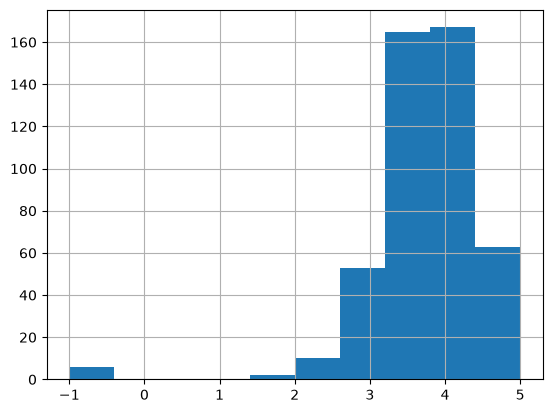

In [274]:
df.rating.hist()

##### Salary per annum

<Axes: >

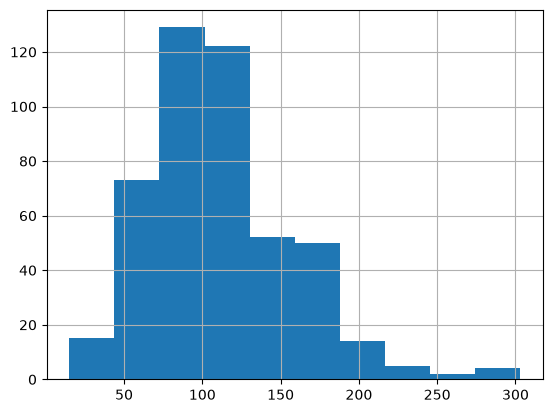

In [275]:
df.avg_salary.hist()

##### Checking the range and outliers

If you dont understand the line and the triangle inside the box, here's what it means
1. Line: 
-   This shows you the median. (Median means the exact middle value when sorted)
2. Green Triangle: 
-   This shows you the mean (Mathematical average value, Sum of all numbers / Count of all the numbers), average is another word for this, but we use mean in data science

<Axes: >

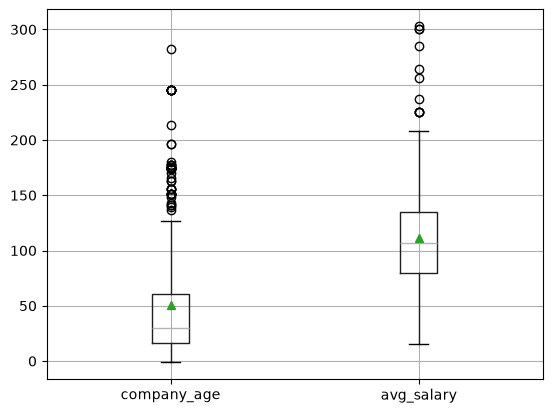

In [276]:
df.boxplot(column= ['company_age', 'avg_salary'], showmeans=True)

<Axes: >

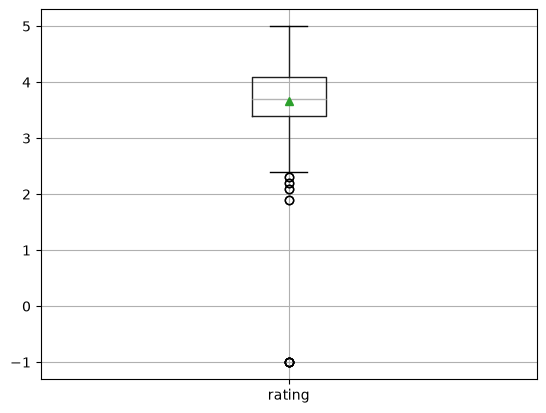

In [277]:
df.boxplot(column=['rating'], showmeans=True)

#### Categorical Fields

We take out categorical fields so we can create graphs based on that and excluding other fields

In [278]:
df_cat = df[[
    'company_age', 'rating', 'avg_salary', 'desc_len', 'location', 'headquarters', 'size', 'type_of_ownership', 'industry', 'sector', 'revenue', 'company_text', 'same_state', 'avg_emp_count', 'python_yn', 'r_yn', 'power_bi_yn', 'sql_yn', 'excel_yn', 'spark_yn', 'seniority', 'competitor_count'
]]

#### Correlation of specific fields

This can show how each fields can be correlated

According to the graph we can identify these things.

1. company_age is highly correlated with avg_emp_count
-  This means that when the company's age is increased/decreased the employee count (avg) can result the same
2. company_age, rating is not correlated with avg_salary
-  This means eventhough the company is old/new or rating is high/low doesn't mean high/low avg salary. (Ex. Increase of company age or rating doesn't mean high salary)

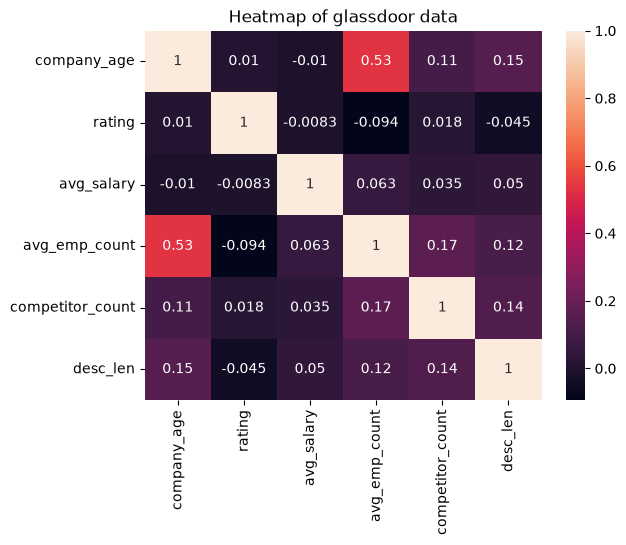

In [279]:
corr = df_cat[['company_age', 'rating', 'avg_salary', 'avg_emp_count', 'competitor_count', 'desc_len']].corr(numeric_only=True) # To check the correlation between numeric only

sns.heatmap(corr, annot=True)
plt.title("Heatmap of glassdoor data")
plt.show()

#### Taking top 50 entries

Graph for the company_age: total = 50 entries


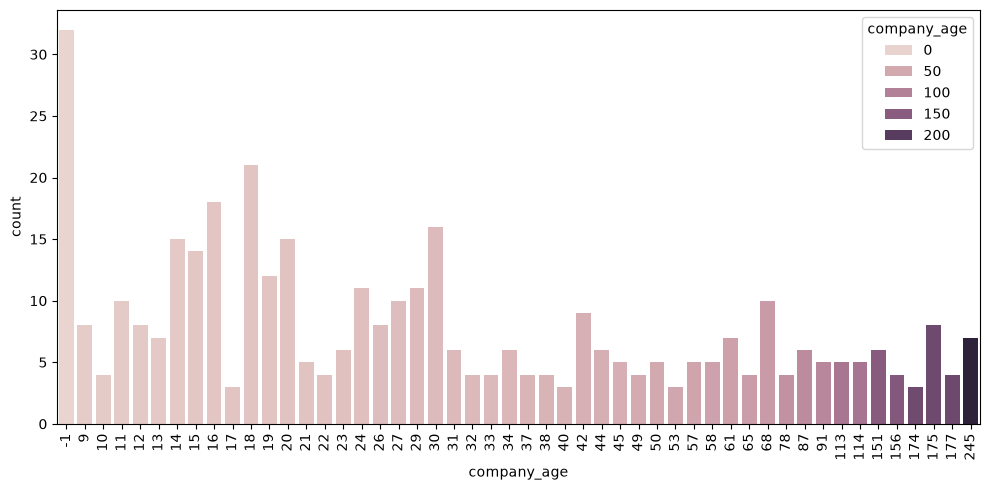

Graph for the rating: total = 31 entries


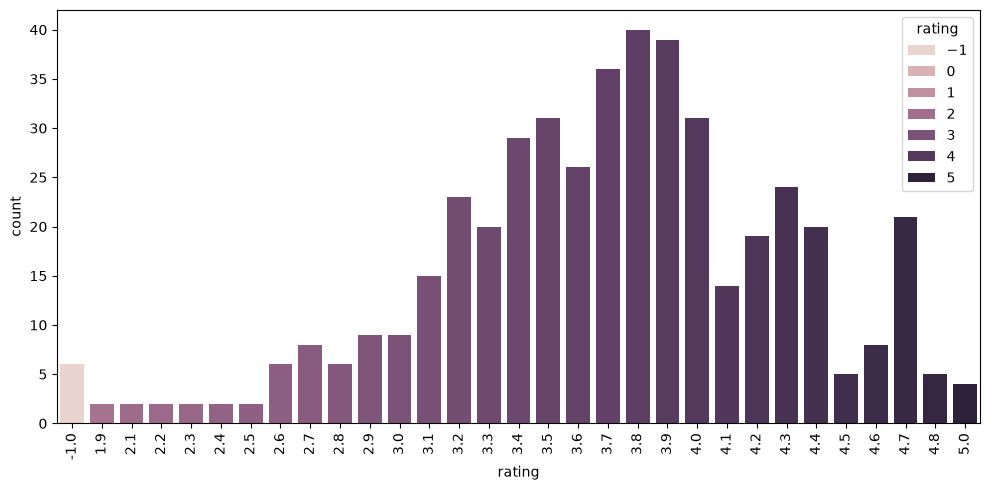

Graph for the avg_salary: total = 50 entries


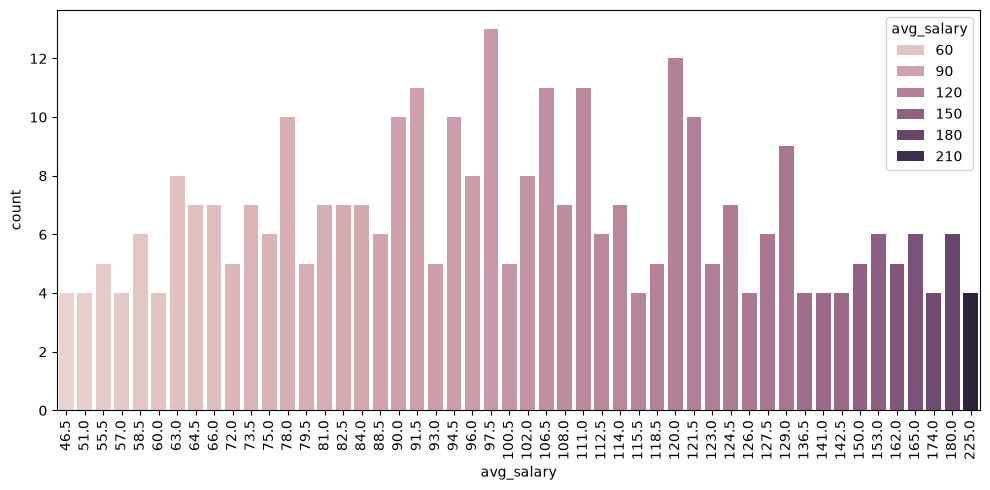

Graph for the desc_len: total = 50 entries


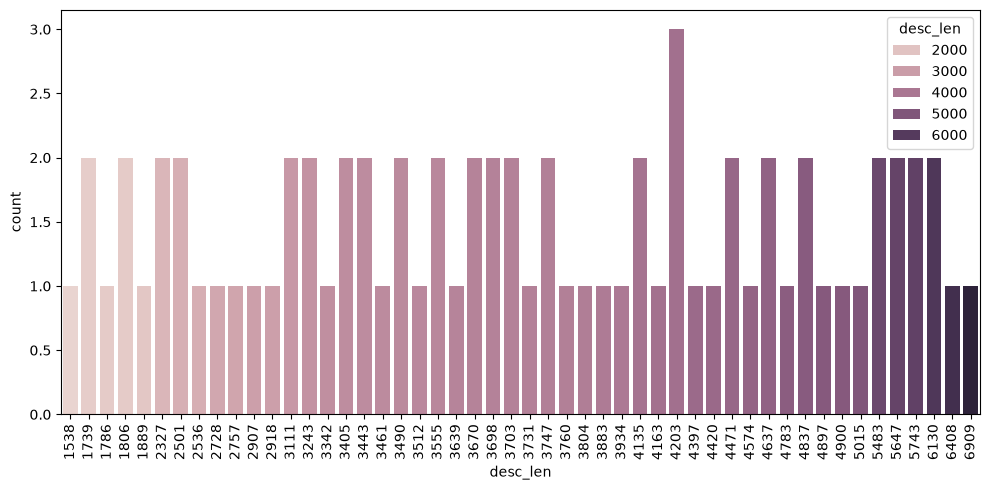

Graph for the location: total = 50 entries


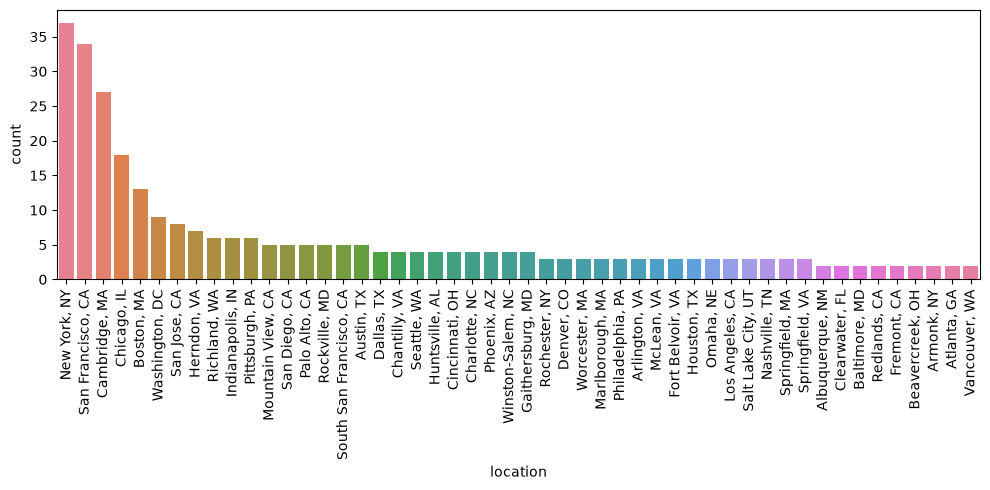

Graph for the headquarters: total = 50 entries


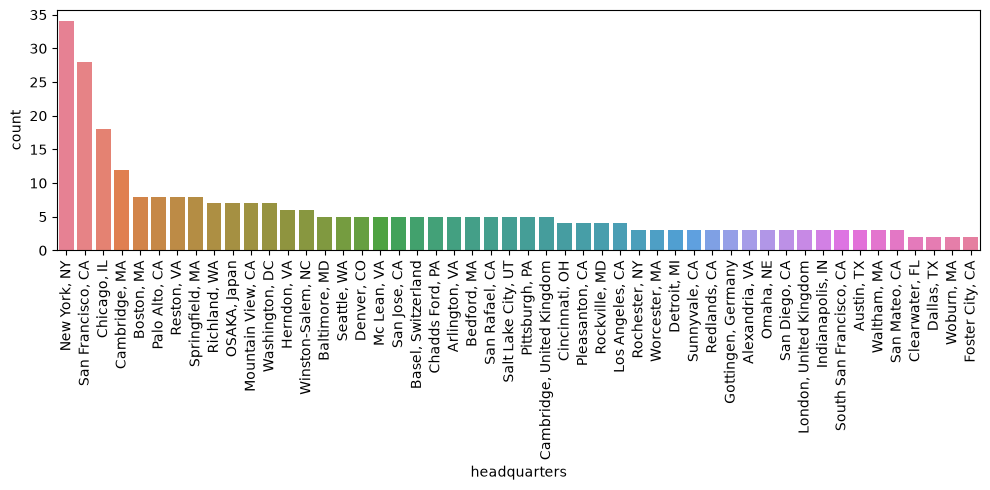

Graph for the size: total = 8 entries


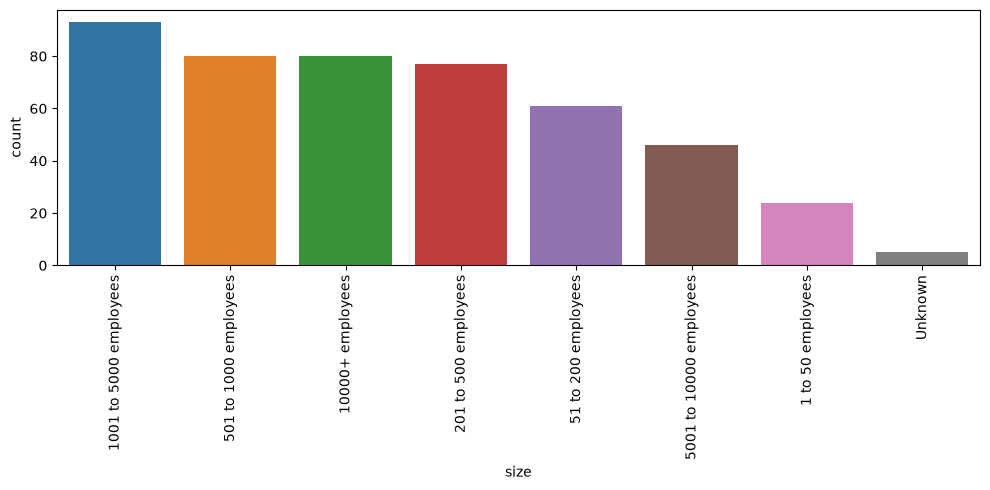

Graph for the type_of_ownership: total = 10 entries


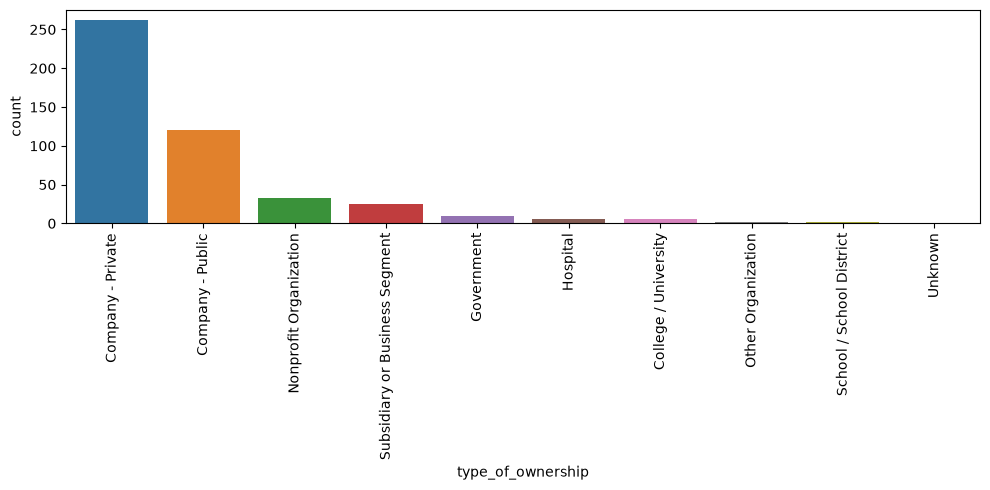

Graph for the industry: total = 50 entries


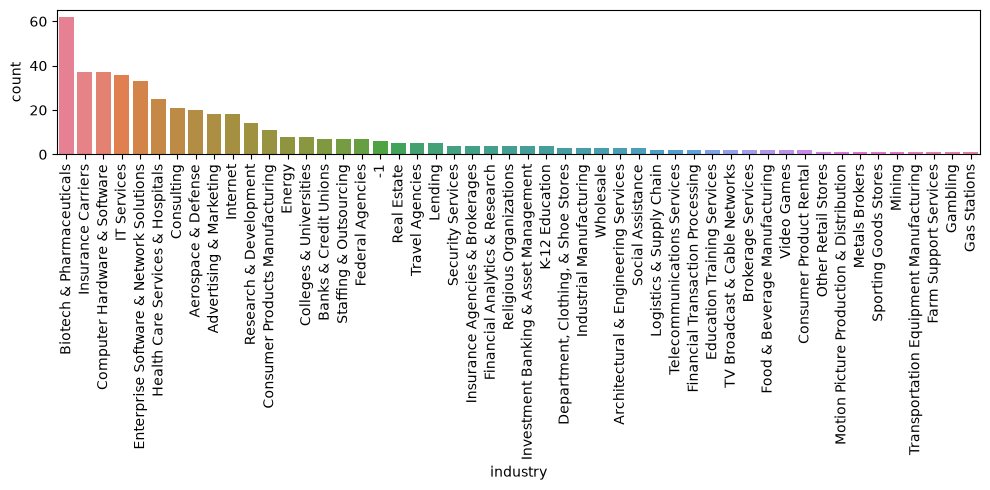

Graph for the sector: total = 25 entries


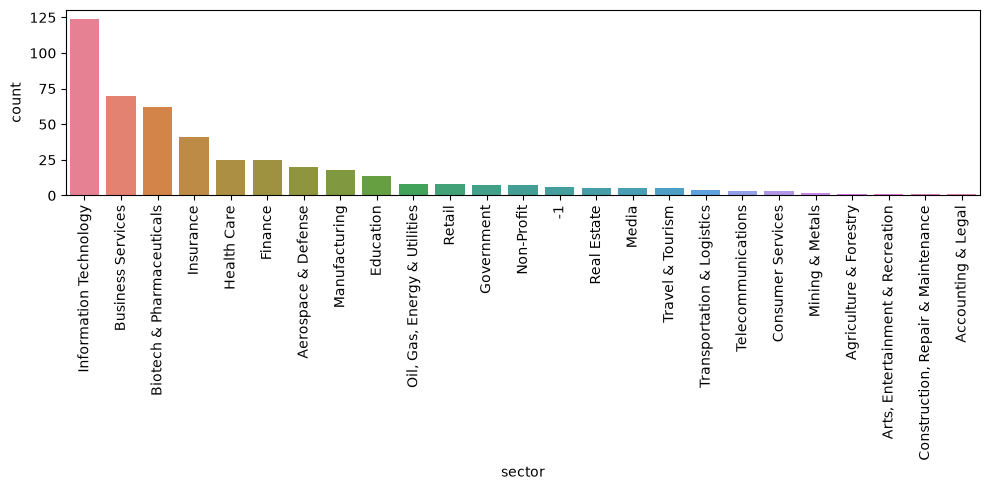

Graph for the revenue: total = 13 entries


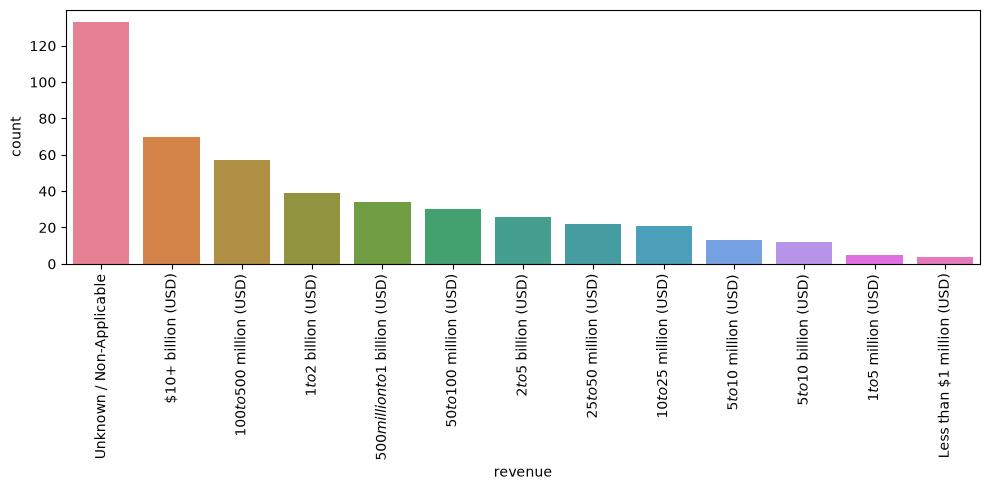

Graph for the company_text: total = 50 entries


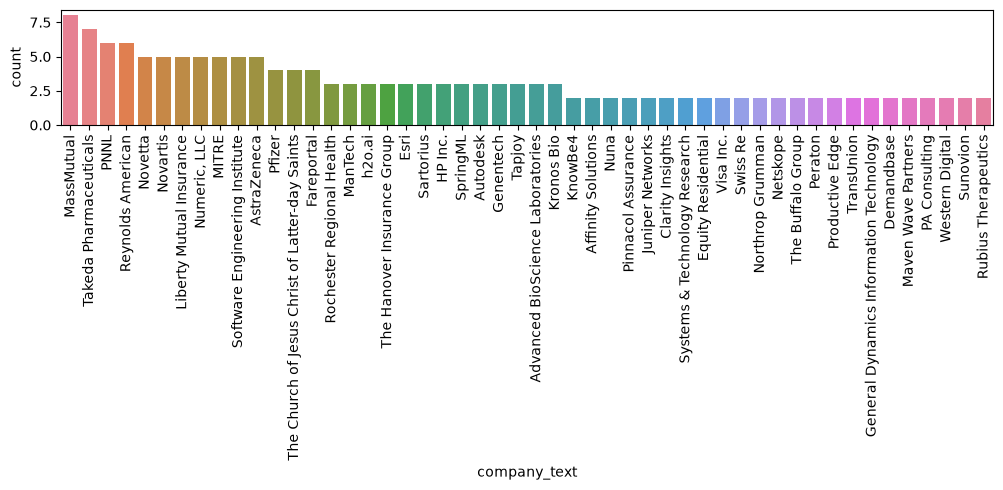

Graph for the same_state: total = 2 entries


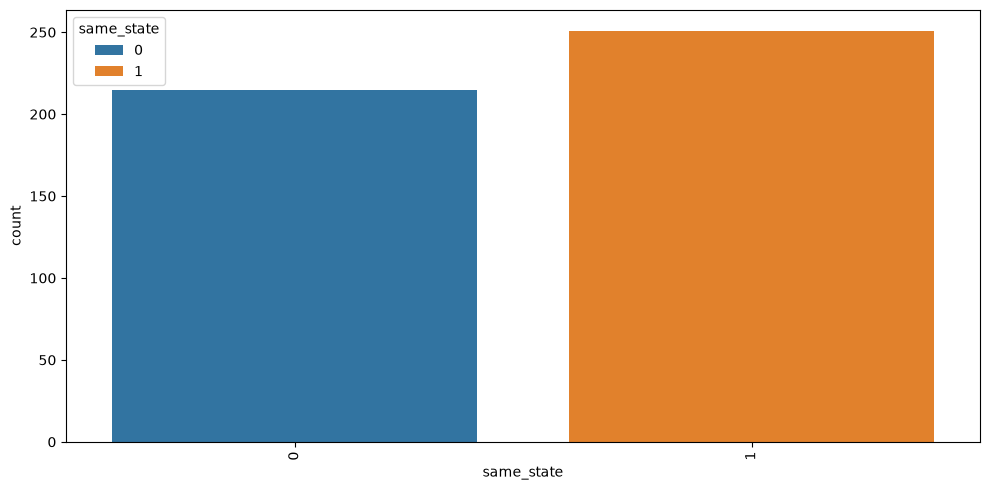

Graph for the avg_emp_count: total = 7 entries


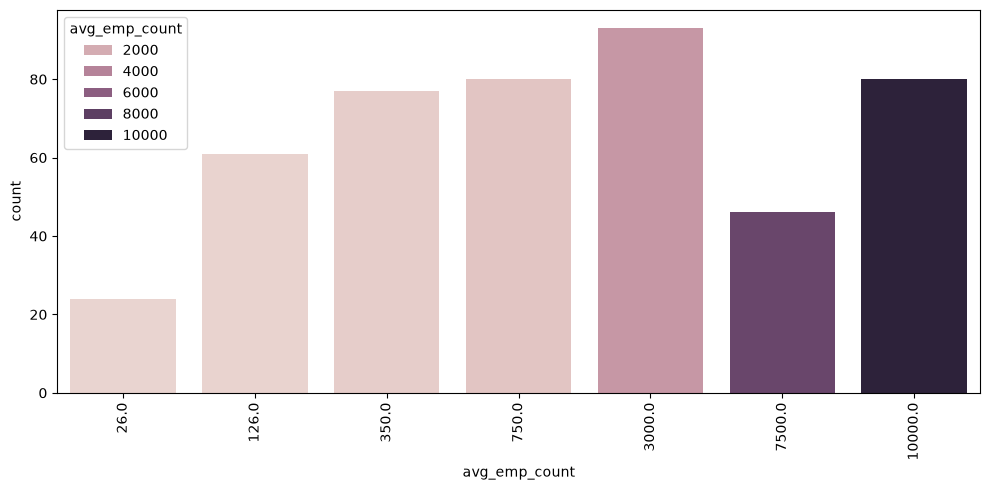

Graph for the python_yn: total = 2 entries


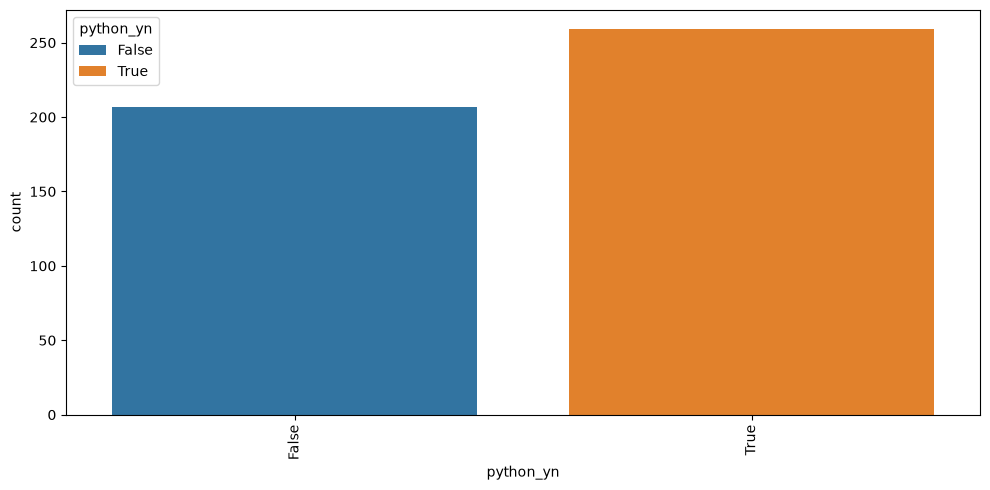

Graph for the r_yn: total = 2 entries


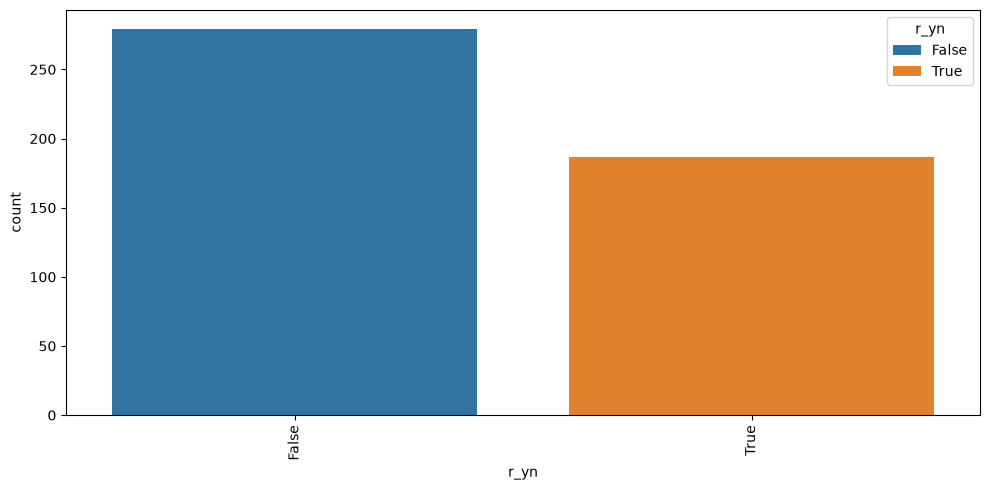

Graph for the power_bi_yn: total = 1 entries


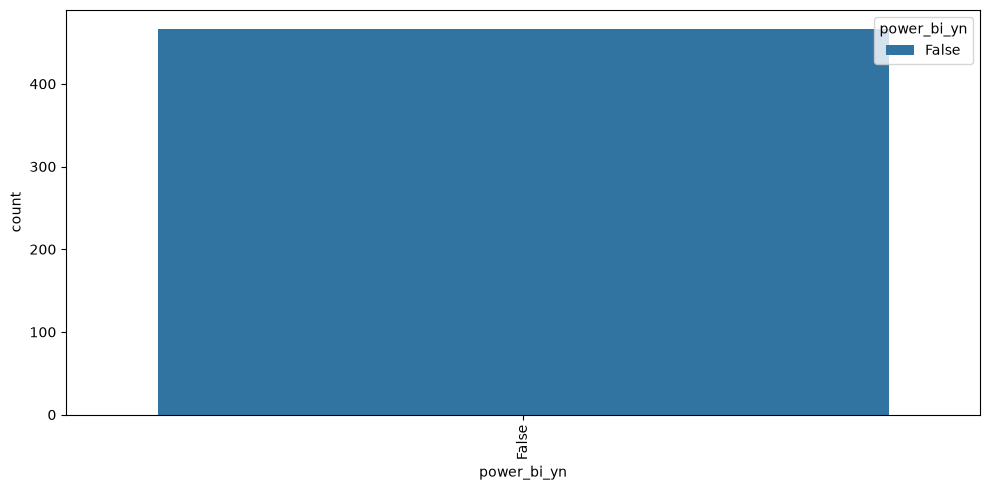

Graph for the sql_yn: total = 2 entries


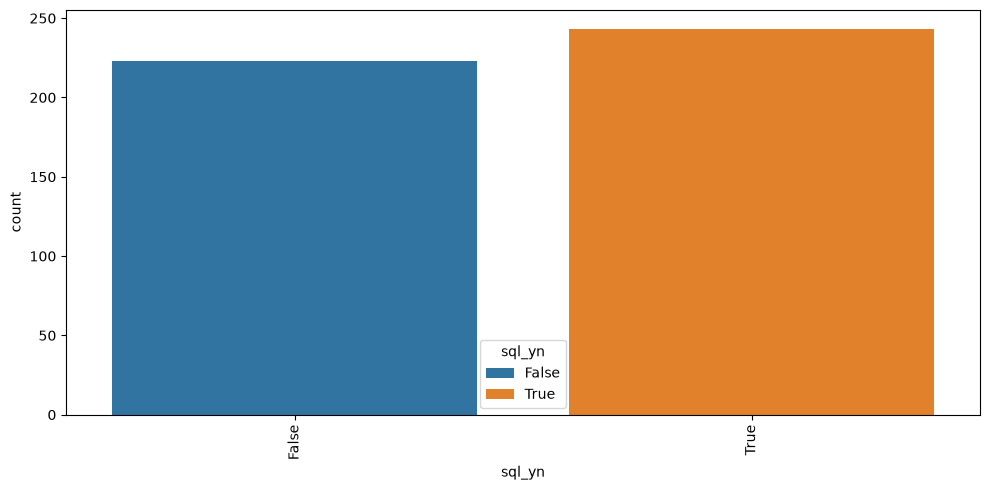

Graph for the excel_yn: total = 2 entries


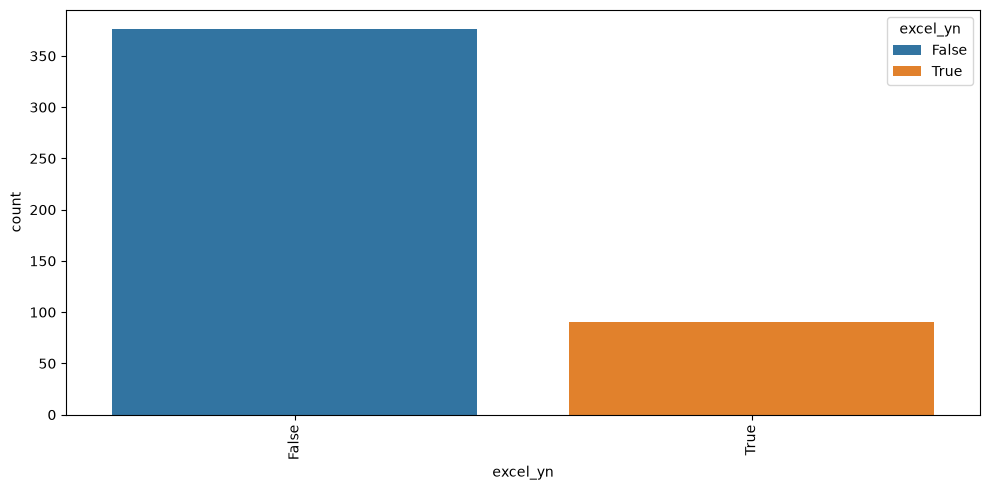

Graph for the spark_yn: total = 2 entries


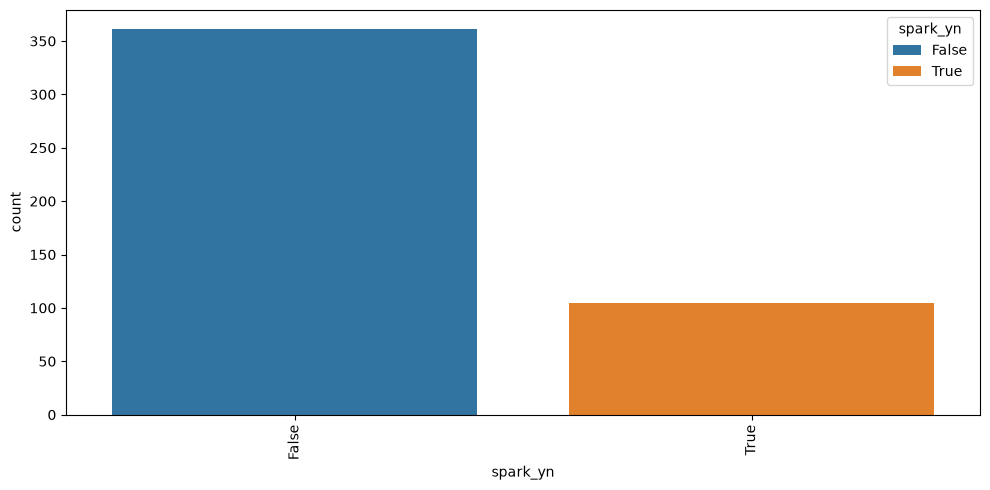

Graph for the seniority: total = 3 entries


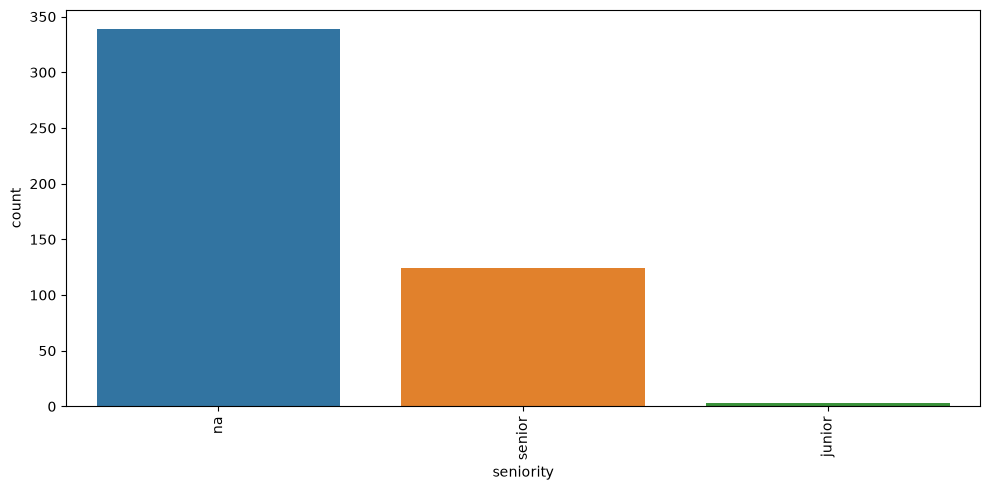

Graph for the competitor_count: total = 5 entries


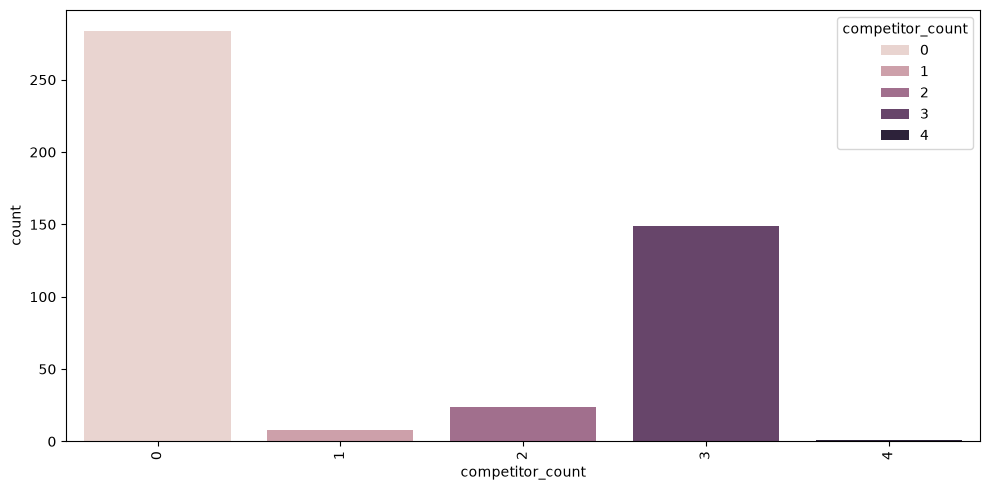

In [280]:
for i in df_cat.columns:
    cat_num = df_cat[i].value_counts()[:50]
    print(f"Graph for the {i}: total = {len(cat_num)} entries")

    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(x=cat_num.index, y=cat_num, hue=cat_num.index, ax=ax)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

#### Pivoting cols for more details on salaries

In [281]:
pd.set_option('display.max_rows', None)

How much each role earns per annum

Based on it

1. Highest Paid: Director ($179K per annum)
2. Lowest Paid: Analyst ($72K per annum)

In [282]:
pd.pivot_table(df, index=['title_simplified'], values='avg_salary')

,avg_salary
title_simplified,
analyst,72.739437
data engineer,110.800000
data scientist,132.539062
director,179.812500
manager,94.000000
mle,138.136364
na,91.886598


How it is based on the seniority

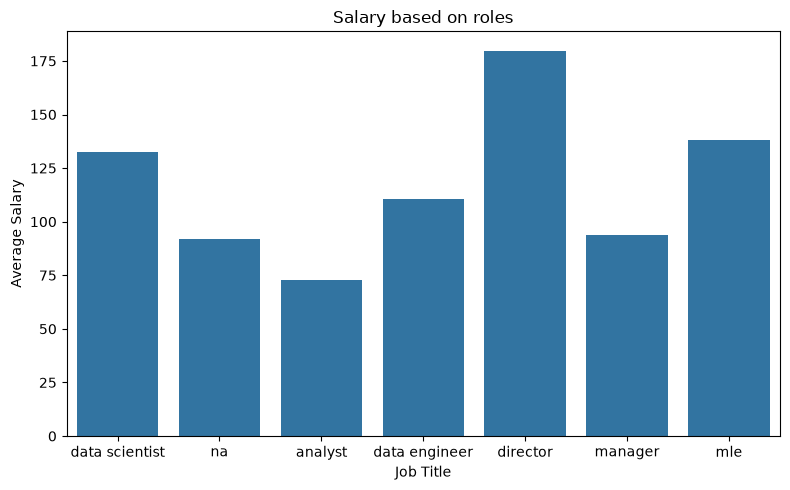

In [283]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(df, x='title_simplified', y='avg_salary', ax=ax, errorbar=None)
ax.set_ylabel("Average Salary")
ax.set_xlabel("Job Title")

plt.title("Salary based on roles")
plt.tight_layout()
plt.show()

In [284]:
pd.pivot_table(df, index=['title_simplified', 'seniority'], values='avg_salary')

avg_salary
title_simplified seniority            
analyst          junior      55.500000
                 na          67.176471
                 senior      90.416667
data engineer    na         102.368421
                 senior     137.500000
data scientist   junior     121.500000
                 na         121.202206
                 senior     160.772727
director         na         179.812500
manager          na          94.000000
mle              na         123.000000
                 senior     178.500000
na               na          79.768657
                 senior     118.950000

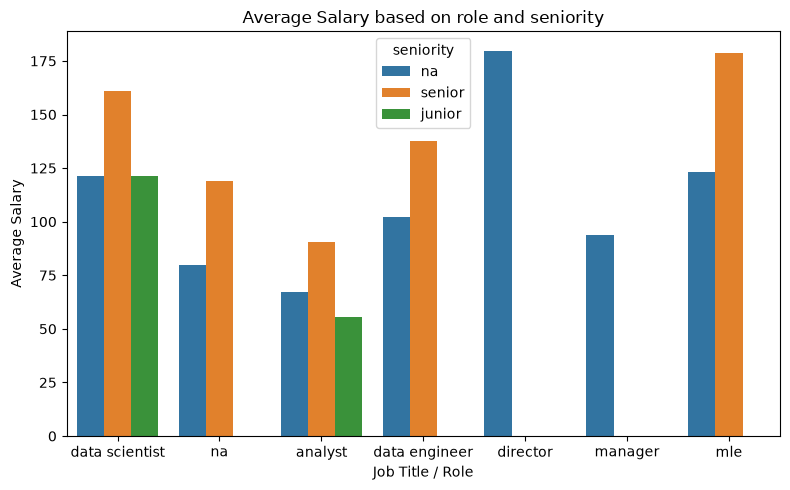

In [285]:
fig ,ax = plt.subplots(figsize=(8, 5))

sns.barplot(df, x='title_simplified', y='avg_salary', hue='seniority', ax=ax, errorbar=None)
ax.set_xlabel('Job Title / Role')
ax.set_ylabel('Average Salary')

plt.title("Average Salary based on role and seniority")
plt.tight_layout()
plt.show()

How it is based on the state

In [286]:
pd.pivot_table(df, index=['job_state'], values='avg_salary')

,avg_salary
job_state,
AL,59.000000
AZ,90.500000
CA,139.377551
CO,93.428571
CT,87.750000
DC,130.000000
DE,31.500000
FL,95.833333
GA,87.000000


Based on the state and the role

In [287]:
pd.pivot_table(df, index=['job_state', 'title_simplified'], values='avg_salary')

avg_salary
job_state title_simplified            
AL        analyst            66.000000
          data engineer      66.000000
          na                 45.000000
AZ        analyst            58.500000
          data engineer      94.500000
          data scientist     76.500000
          na                124.500000
CA        analyst            95.500000
          data engineer     137.600000
          data scientist    161.138298
          manager           111.750000
          mle               197.000000
          na                108.088235
CO        analyst            30.000000
          data engineer     111.000000
          data scientist    123.000000
          mle               108.000000
          na                 36.000000
CT        data scientist     94.500000
          na                 81.000000
DC        analyst            69.000000
          data engineer      95.000000
          data scientist    186.750000
DE        na                 31.500000
FL        analyst            51.000000
          data engineer     126.000000
          data scientist    114.375000
GA        data scientist     93.000000
          na                 75.000000
IA        analyst            46.500000
          data engineer     102.750000
ID        analyst            59.250000
IL        analyst            72.750000
          data engineer     103.750000
          data scientist    123.375000
          director          245.500000
          mle               150.000000
          na                 68.250000
IN        data engineer     111.750000
          data scientist     94.500000
          na                 77.000000
KS        mle                91.500000
KY        data scientist     94.500000
          na                102.000000
LA        analyst            51.000000
          data engineer      72.000000
          data scientist    123.000000
          na                 22.500000
MA        analyst            66.500000
          data engineer     109.250000
          data scientist    125.052632
          director          129.000000
          manager            69.500000
          na                116.500000
MD        analyst            87.000000
          data engineer     114.000000
          data scientist    127.666667
          na                 89.666667
MI        data scientist    136.000000
          manager            88.500000
MN        analyst            82.500000
          data engineer      97.500000
MO        analyst            66.000000
          data scientist    136.500000
          manager            39.000000
          na                 67.500000
NC        data engineer     112.500000
          data scientist    129.750000
          na                 90.000000
NE        na                 46.000000
NJ        analyst            89.400000
          data engineer     117.000000
          data scientist    127.000000
          director          186.000000
          manager           127.500000
          na                 78.000000
NM        data scientist     81.750000
NY        analyst            70.333333
          data engineer      96.500000
          data scientist    129.910714
          mle               136.500000
          na                 86.000000
OH        analyst            63.750000
          data scientist    117.000000
          na                 87.750000
OR        data engineer      73.500000
          data scientist    111.750000
PA        analyst            66.900000
          data engineer      94.500000
          data scientist    130.125000
          manager           108.750000
          mle               116.500000
          na                 90.000000
RI        analyst           111.000000
SC        na                 58.500000
TN        analyst            15.000000
          data engineer     106.800000
          data scientist    105.000000
TX        data engineer     112.800000
          data scientist    109.833333
          na                 54.000000
UT        a

Count of job postings in each state based on the role

In [288]:
pd.pivot_table(df, index=['job_state', 'title_simplified'], values='avg_salary', aggfunc='count').sort_values(by='avg_salary', ascending=False)

avg_salary
job_state title_simplified            
CA        data scientist            47
NY        data scientist            28
MA        na                        24
          data scientist            19
CA        na                        17
          data engineer             15
VA        data scientist            15
CA        analyst                   12
WA        data scientist            11
TX        data scientist             9
NY        analyst                    9
MD        data scientist             9
          na                         9
IL        data scientist             8
VA        data engineer              8
IL        data engineer              6
MA        data engineer              6
NY        na                         6
PA        analyst                    5
NJ        analyst                    5
NC        na                         5
TN        data engineer              5
TX        data engineer              5
OH        data scientist             5
CA        manager                    4
FL        data scientist             4
DC        data scientist             4
PA        data scientist             4
          na                         4
MA        director                   4
VA        analyst                    4
NC        data engineer              4
UT        analyst                    3
TX        na                         3
WA        analyst                    3
MA        analyst                    3
          manager                    3
MD        analyst                    3
MI        data scientist             3
NE        na                         3
NY        data engineer              3
PA        mle                        3
NJ        data scientist             3
DC        data engineer              3
FL        analyst                    3
AL        analyst                    3
AZ        data engineer              3
CA        mle                        3
CO        data scientist             3
IL        director                   3
IN        na                         3
WI        data scientist             2
UT        data engineer              2
VA        na                         2
WI        analyst                    2
PA        manager                    2
OR        data scientist             2
NM        data scientist             2
OH        na                         2
NC        data scientist             2
NJ        data engineer              2
MO        na                         2
          data scientist             2
ID        analyst                    2
KY        na                         2
IN        data scientist             2
OH        analyst                    2
DC        analyst                    2
DE        na                         2
IL        na                         2
FL        data engineer              2
GA        data scientist             2
IN        data engineer              2
AL        na                         2
IL        analyst                    2
IA        data engineer              2
AZ        data scientist             1
AL        data engineer              1
AZ        analyst                    1
CO        data engineer              1
          mle                        1
          na                         1
CT        data scientist             1
LA        na                         1
          analyst                    1
          data engineer              1
          data scientist             1
KS        mle                        1
IL        mle                        1
KY        data scientist             1
GA        na                         1
IA        analyst                    1
CT        na                         1
AZ        na                         1
CO        analyst                    1
MD        data engineer              1
MI        manager                    1
MN        analyst                    1
MO        manager                    1
NY        mle                        1
NJ        na                         1
          d

Average salary in each state

In [289]:
pd.pivot_table(df[df['title_simplified'] == 'data scientist'], index='job_state', values='avg_salary').sort_values(by='avg_salary', ascending=False)

,avg_salary
job_state,
DC,186.750000
UT,162.000000
CA,161.138298
MO,136.500000
MI,136.000000
PA,130.125000
NY,129.910714
NC,129.750000
MD,127.666667


Average Salary based on the job state

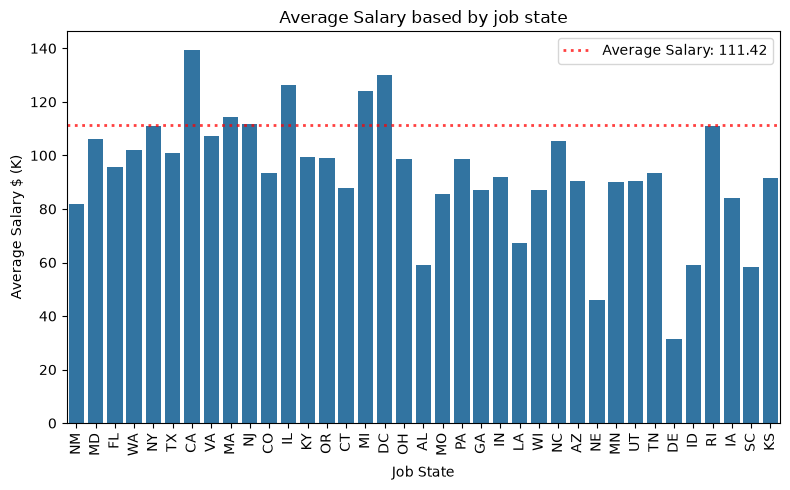

In [290]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(df, x='job_state', y='avg_salary', ax=ax, errorbar=None)

mean = df['avg_salary'].mean()

ax.axhline(mean, color='red', lw=2, alpha=0.75, linestyle='dotted', label=f'Average Salary: {mean:.2f}')
ax.legend()
ax.set_title('Average Salary based by job state')
ax.set_xlabel('Job State')
ax.set_ylabel('Average Salary $ (K)')
ax.tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()

Plots that showcase average salary based on some other factors

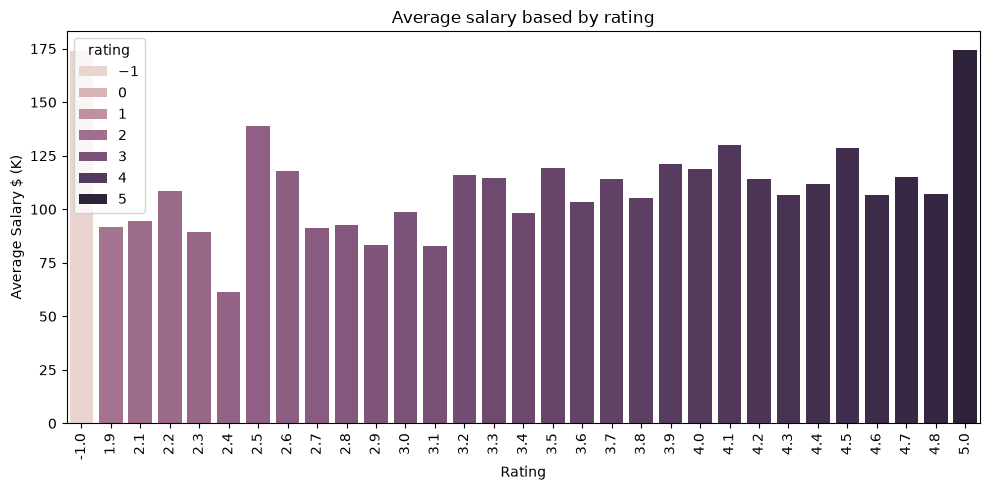

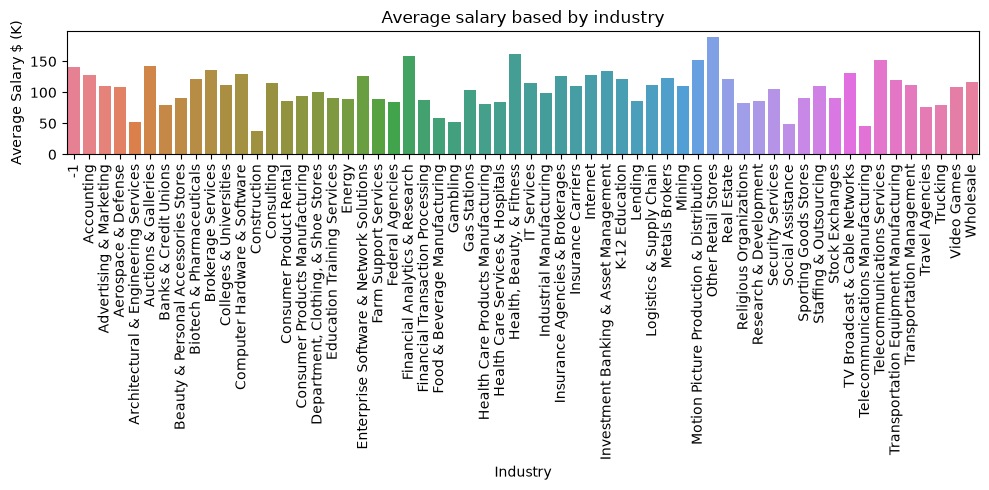

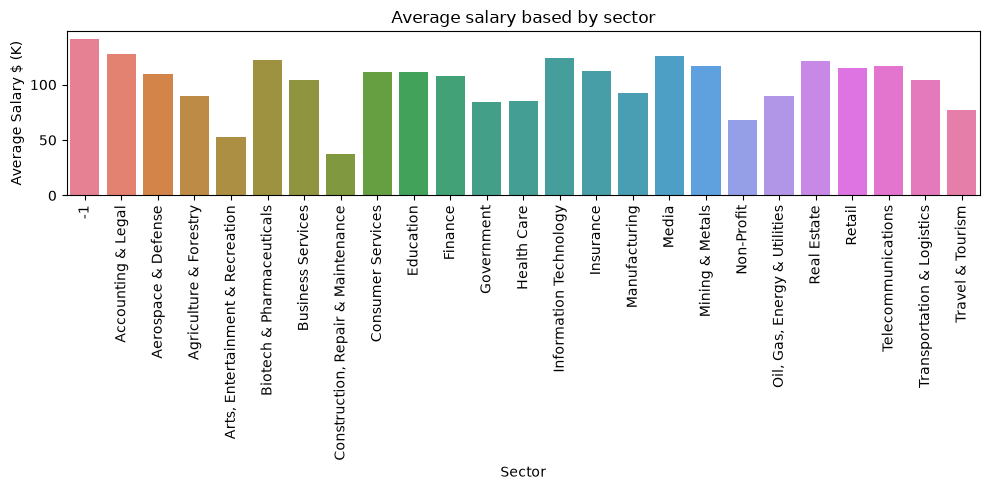

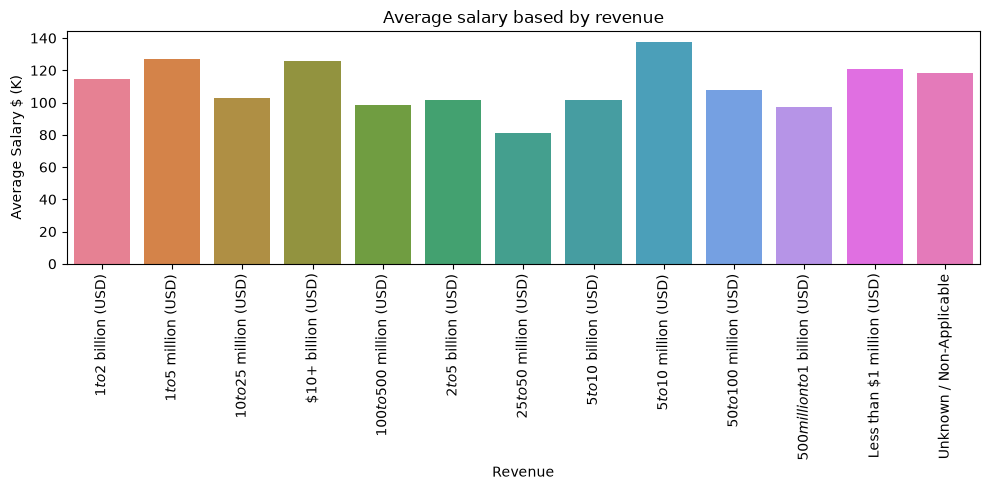

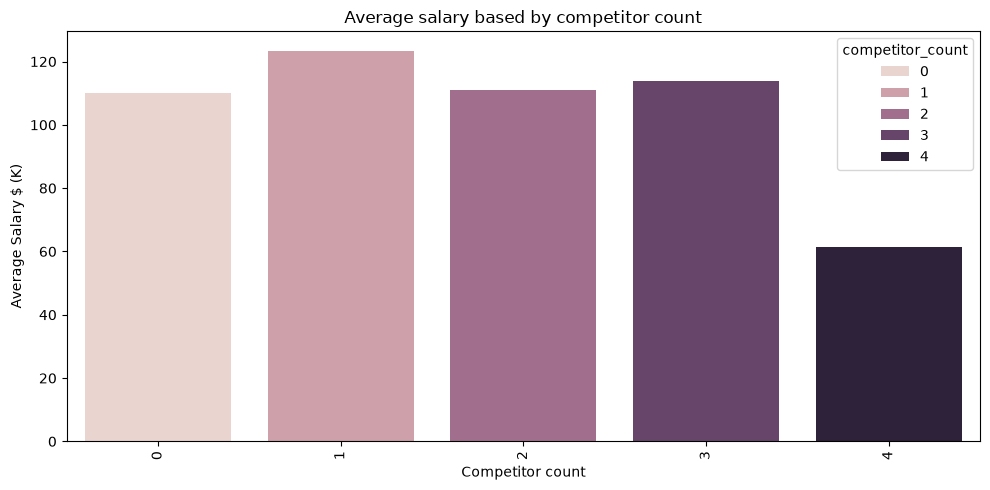

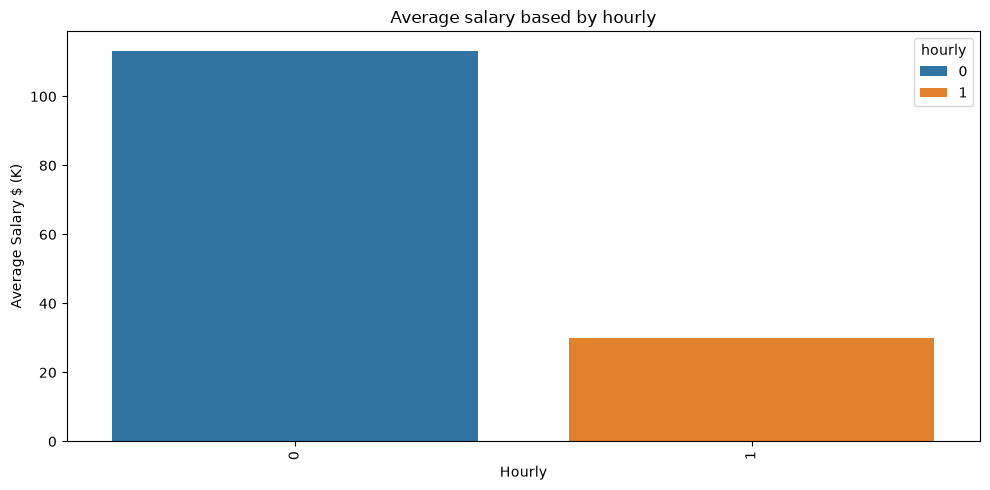

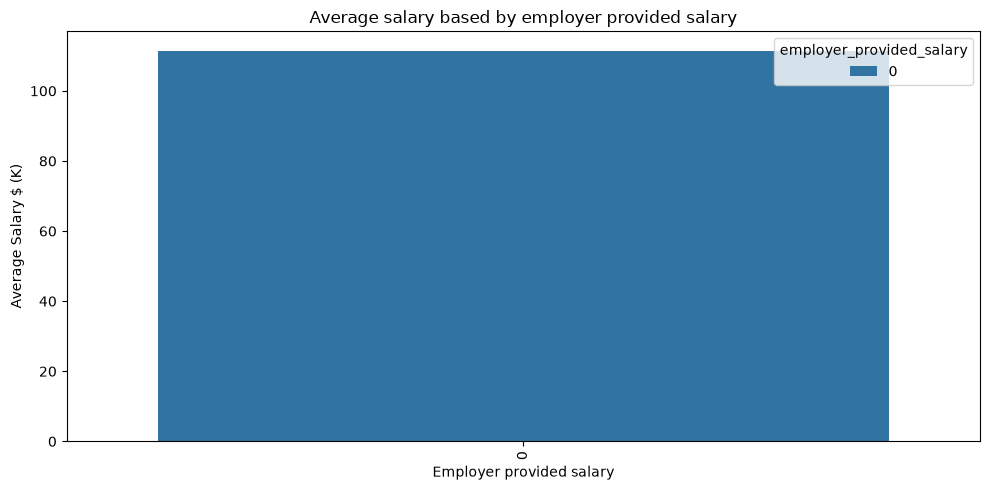

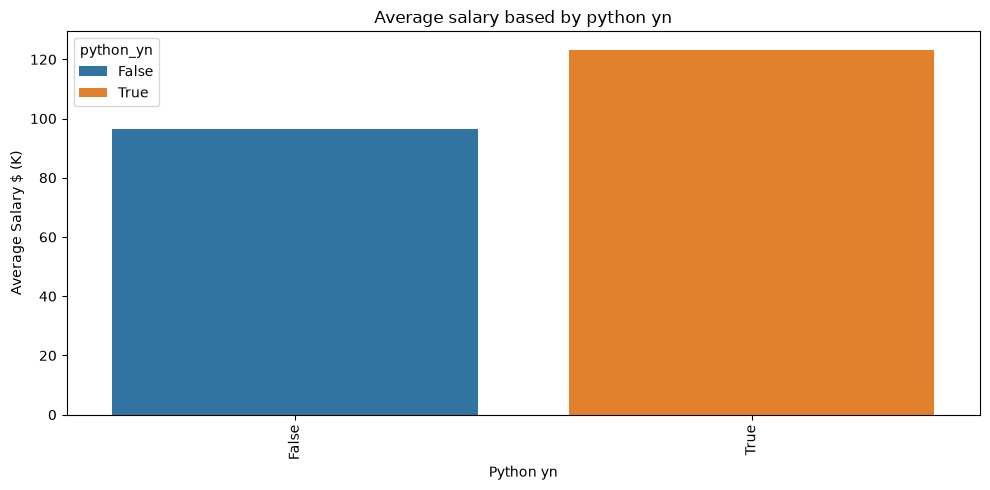

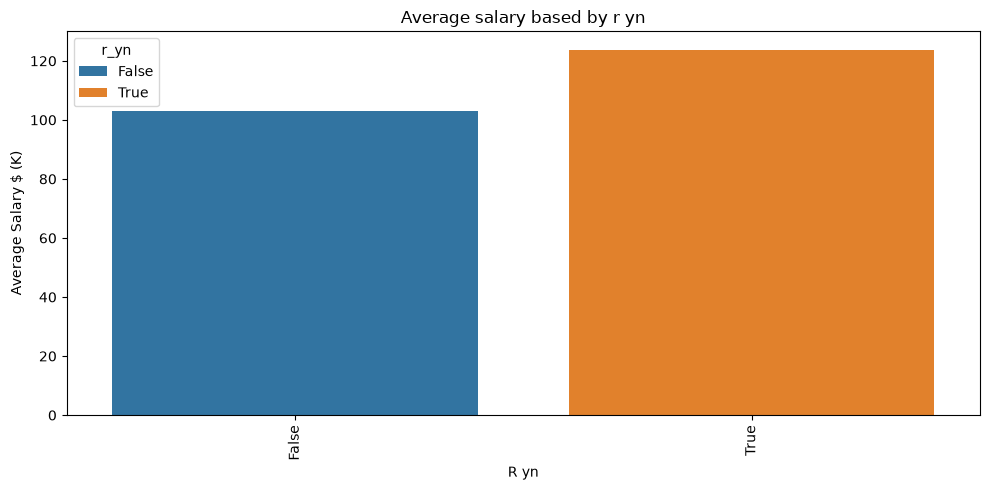

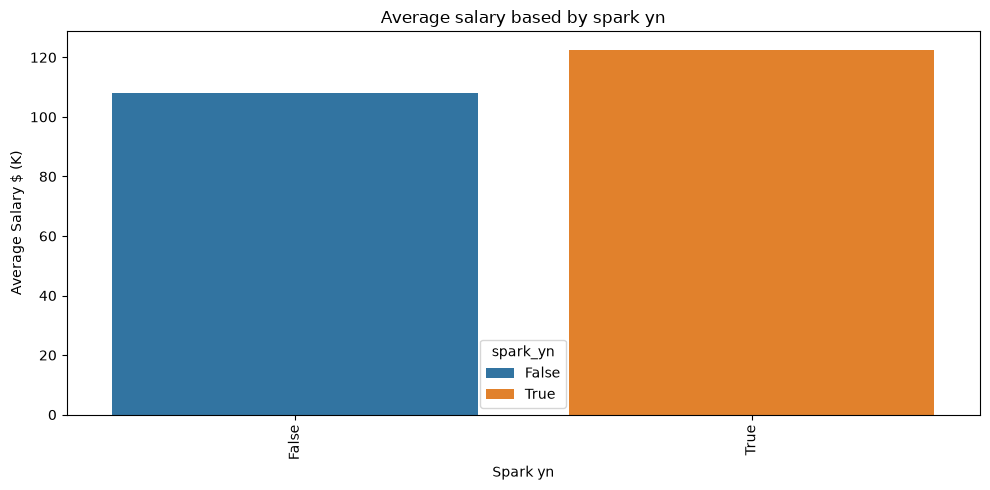

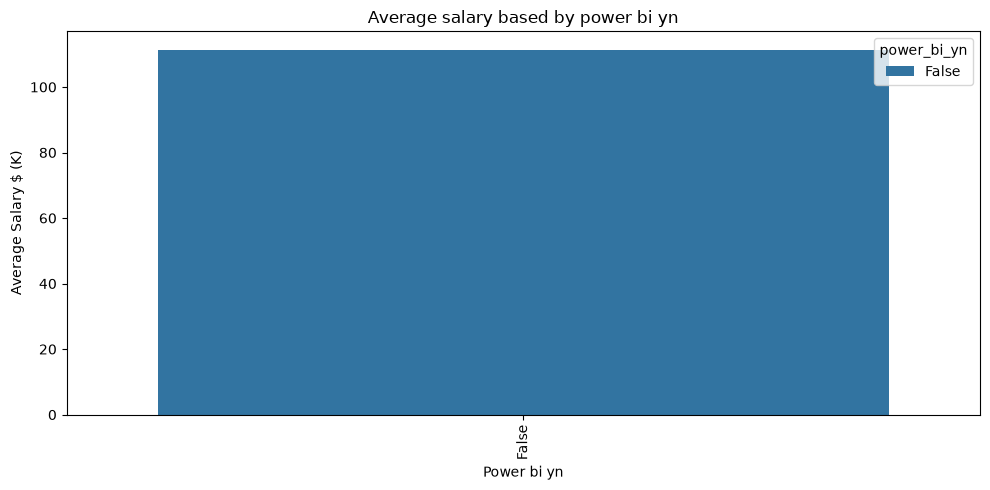

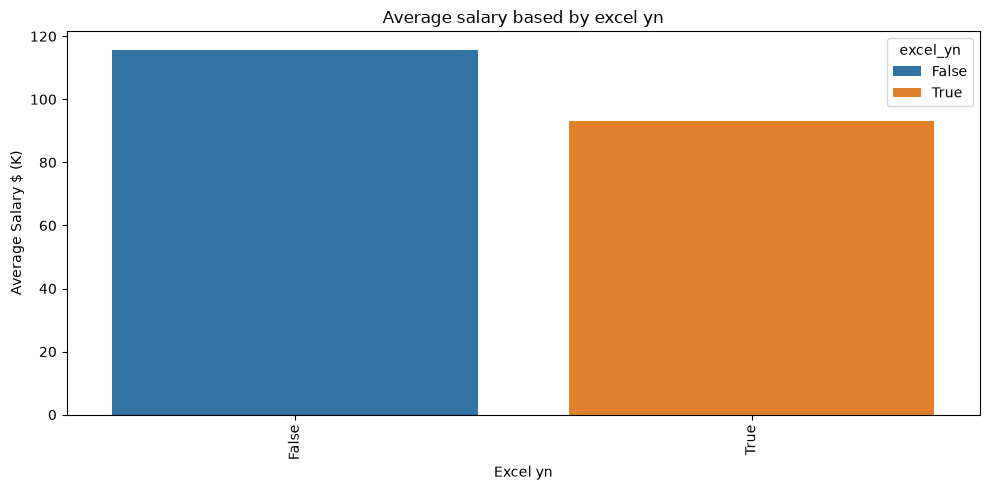

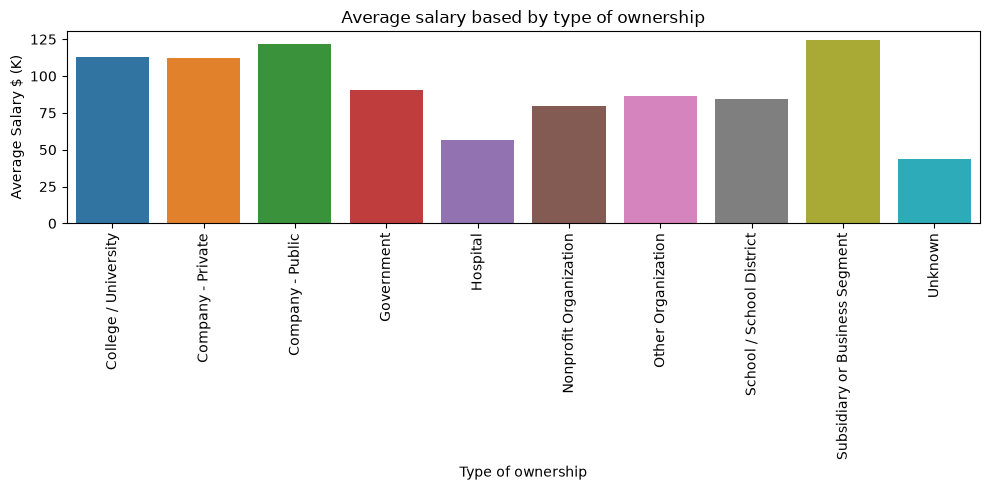

In [291]:
df_pivots = df[['rating', 'industry', 'sector', 'revenue', 'competitor_count', 'hourly', 'employer_provided_salary', 'python_yn', 'r_yn', 'spark_yn', 'power_bi_yn', 'excel_yn', 'type_of_ownership']]


for i in df_pivots:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(df.sort_values(by=i, ascending=True), x=i, y='avg_salary', hue=i, errorbar=None)
    ax.set_title(f"Average salary based by {i.replace('_', ' ')}")
    ax.set_xlabel(i.replace('_', ' ').capitalize())
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Average Salary $ (K)')

    plt.tight_layout()
    plt.show()

##### Extra: How much a companies pay for python skill based on revenue in the company

This shows that for high salaries, learning python is a must.

In [292]:
pd.pivot_table(df_cat, index='revenue', columns='python_yn', values='avg_salary').sort_values(by=True, ascending=False)

python_yn,False,True
revenue,,
$5 to $10 million (USD),121.750000,150.642857
$10+ billion (USD),111.527027,142.136364
Less than $1 million (USD),102.000000,127.500000
Unknown / Non-Applicable,108.736364,125.500000
$1 to $2 billion (USD),90.000000,124.392857
$1 to $5 million (USD),131.250000,124.000000
$50 to $100 million (USD),86.538462,123.970588
$5 to $10 billion (USD),80.250000,122.750000
$2 to $5 billion (USD),78.409091,118.900000


According to the companies revenue, which revenued companies are looking for the python skill the most

In [293]:
pd.pivot_table(df, index='revenue', columns='python_yn', values='avg_salary', aggfunc='count').sort_values(by=True, ascending=False)

python_yn,False,True
revenue,,
Unknown / Non-Applicable,55,78
$10+ billion (USD),37,33
$100 to $500 million (USD),24,33
$1 to $2 billion (USD),11,28
$500 million to $1 billion (USD),16,18
$50 to $100 million (USD),13,17
$2 to $5 billion (USD),11,15
$10 to $25 million (USD),11,10
$25 to $50 million (USD),14,8
